# Water potability prediction

## Library importations

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

## Data importation and data cleaning

In [2]:
data = pd.read_csv(r'C:\Users\ACER\Documents\Club IA - FA 2025\Dataset\water_potability.csv', sep = ";")
data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
print(data.isna().sum().sum()) ##Number of NA

1434


In [4]:
df_clean = data.dropna() ## Cleaning of NA values

## Exploratory Data Analysis

In [5]:
df_clean.describe() ##Summary of dataset 

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000
mean,7.085990,195.968072,21917.441374,7.134338,333.224672,426.526409,14.357709,66.400859,3.969729,0.403282
std,1.573337,32.635085,8642.239815,1.584820,41.205172,80.712572,3.324959,16.077109,0.780346,0.490678
min,0.227499,73.492234,320.942611,1.390871,129.000000,201.619737,2.200000,8.577013,1.450000,0.000000
25%,6.089723,176.744938,15615.665390,6.138895,307.632511,366.680307,12.124105,55.952664,3.442915,0.000000
50%,7.027297,197.191839,20933.512750,7.143907,332.232177,423.455906,14.322019,66.542198,3.968177,0.000000
75%,8.052969,216.441070,27182.587067,8.109726,359.330555,482.373169,16.683049,77.291925,4.514175,1.000000
max,14.000000,317.338124,56488.672413,13.127000,481.030642,753.342620,27.006707,124.000000,6.494749,1.000000


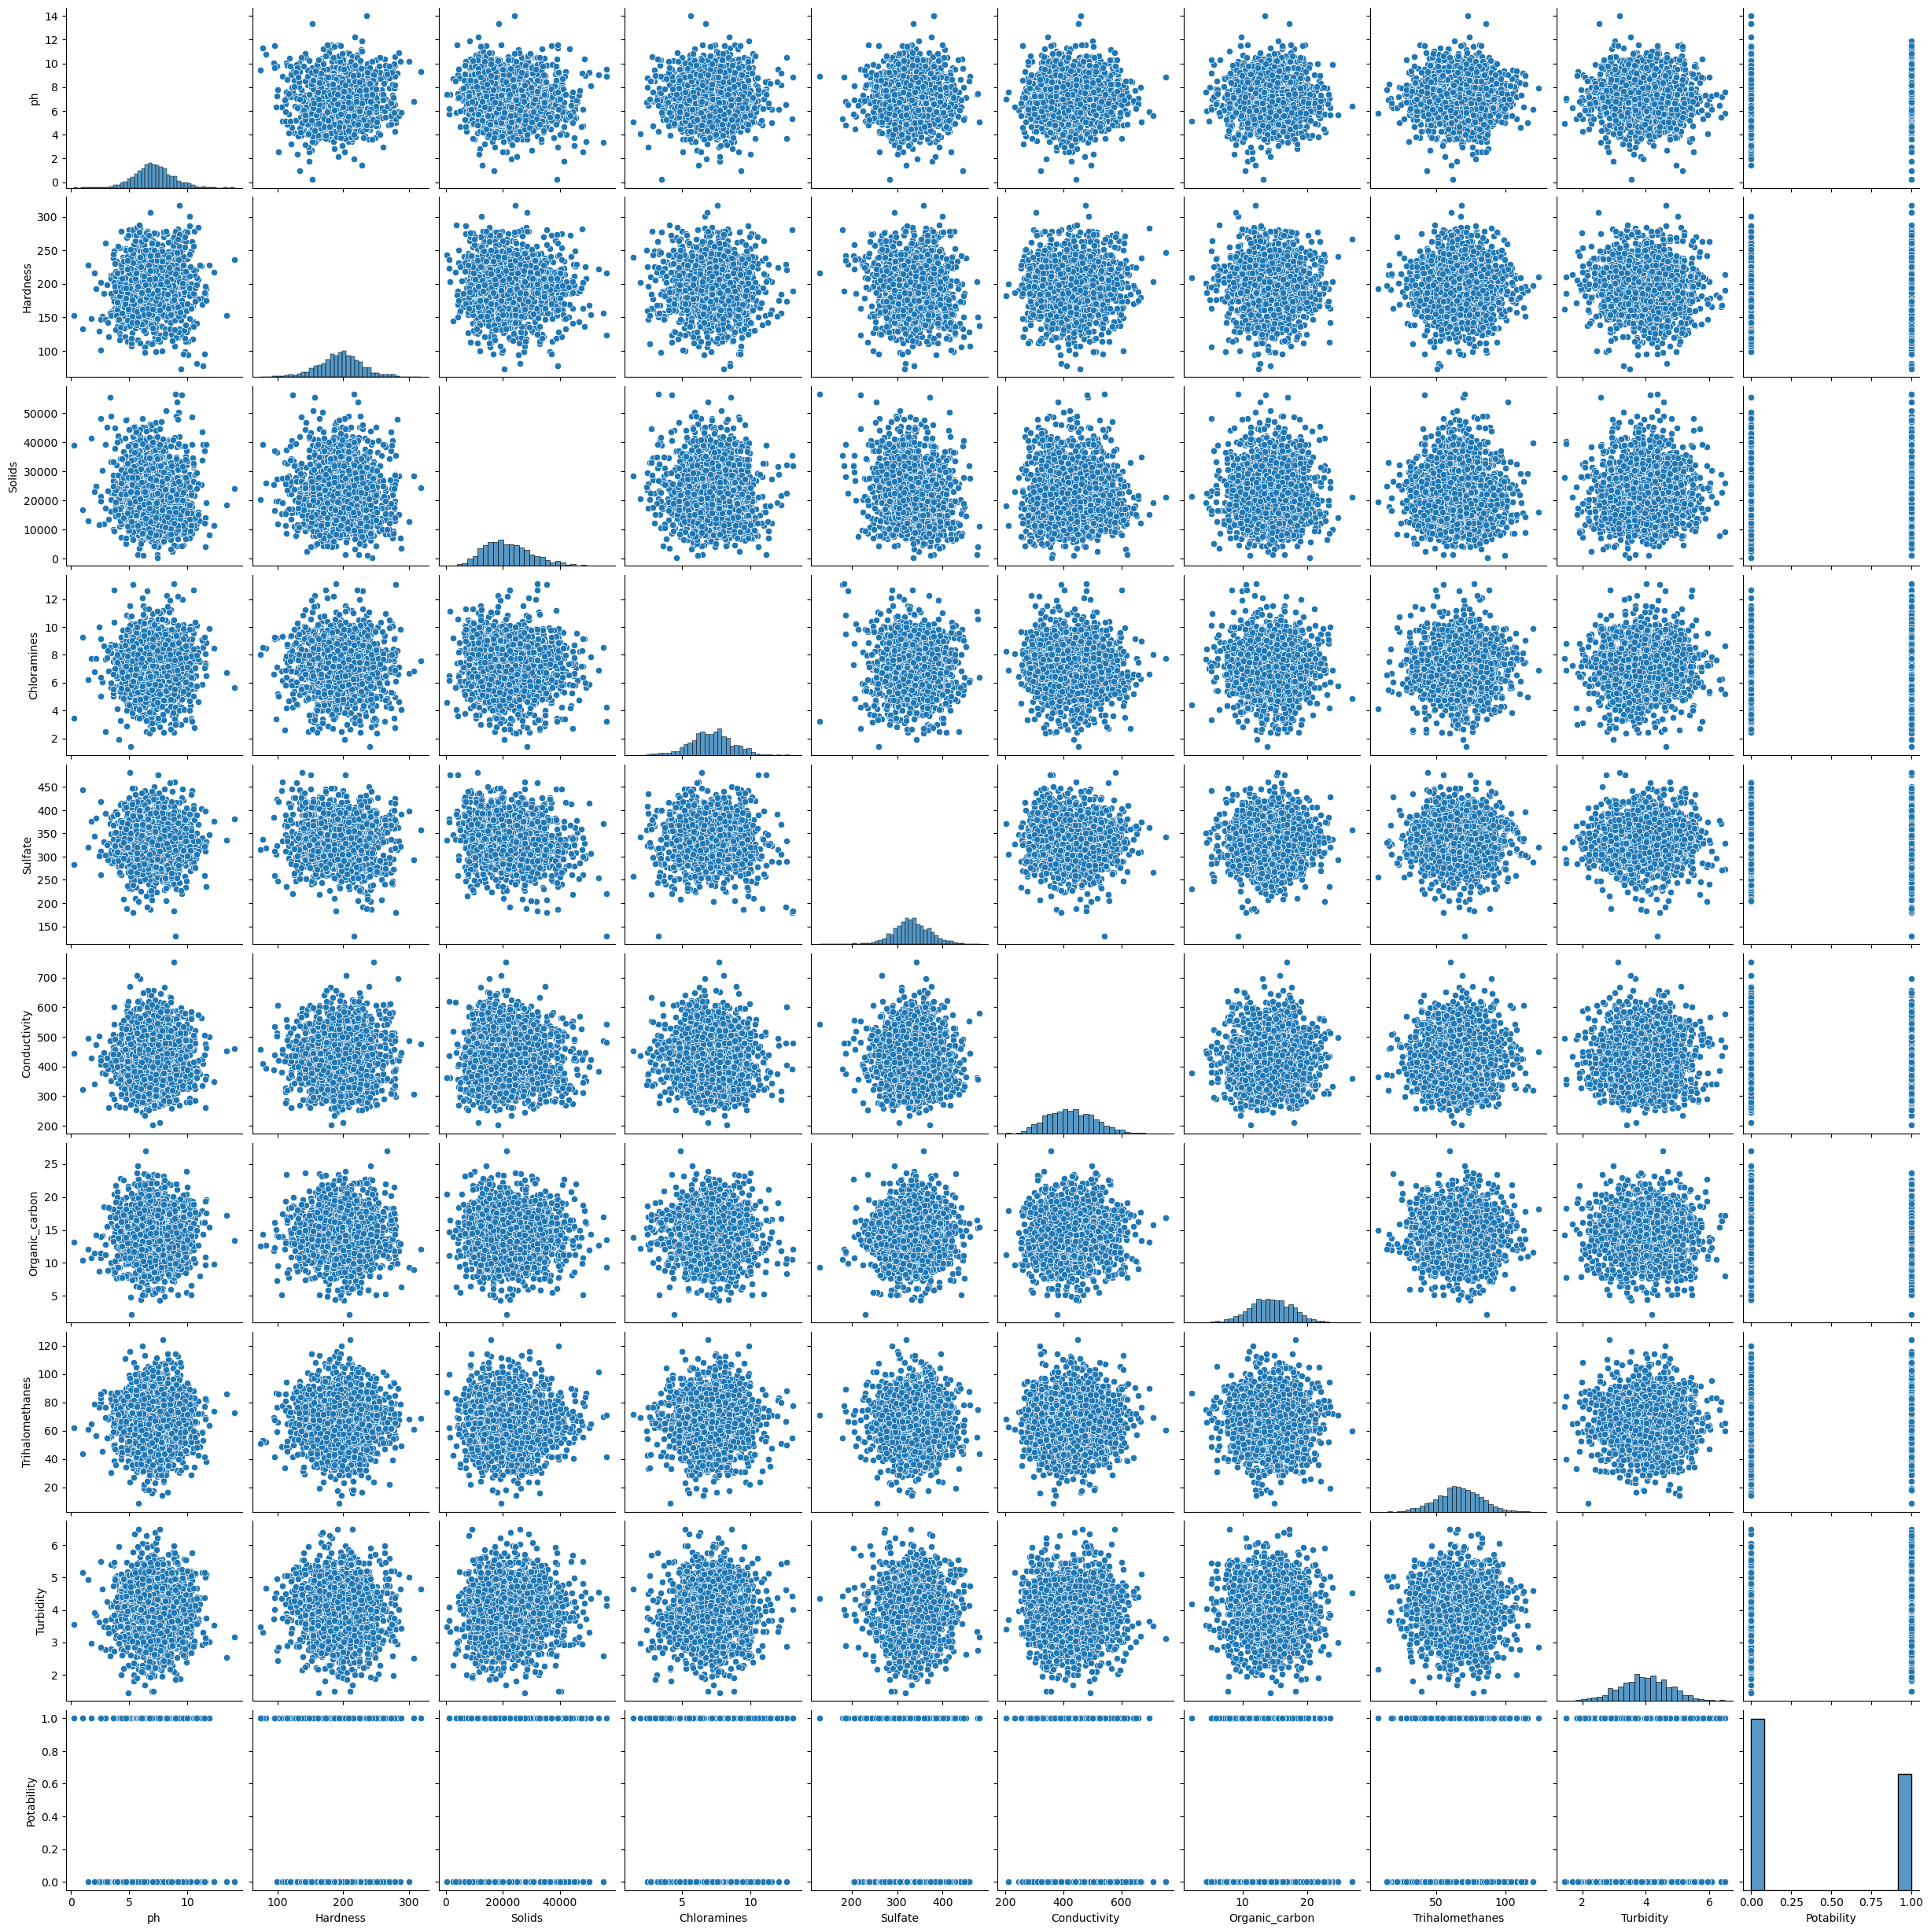

In [6]:
sns.pairplot(df_clean) ##Pairplot 
plt.show()

## Preprocessing of machine learning 

### Libraries importations 

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier 
from sklearn.svm import SVC
from sklearn.metrics import recall_score, f1_score, roc_auc_score 
from sklearn.pipeline import Pipeline

### Data split

In [8]:
y = df_clean['Potability']
x = df_clean.drop('Potability', axis = 1)

##Split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

### Model implementations 

In [9]:
models = {
    'RF' : RandomForestClassifier(random_state = 42), ##Random Forest model
    'LR' : LogisticRegression() , ###Logistic Regression model
    'AdaBoost' : AdaBoostClassifier(n_estimators = 100, learning_rate = 50), ##Ada Boost model
    'SVM': SVC(probability = True), ##SVM model
    'XGB' : xgb.XGBClassifier(objective = 'binary:logistic', learning_rate = 0.1, random_state = 42, n_estimators = 100), #XGBoost model 
    'GradientBoosting' : GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, random_state = 42) ##Gradient Boosting model
}

## Model training and evaluation

In [33]:
import warnings
warnings.filterwarnings("ignore")
results = []
for name, model in models.items() : 
    pipe = Pipeline([('Scaler', StandardScaler()), ('Model', model)])
    pipe.fit(x_train, y_train)
    scores = cross_val_score(pipe, x_train, y_train, cv = 5, scoring = 'recall')

    ##Prediction 
    y_pred = pipe.predict(x_test) 
    y_proba = pipe.predict_proba(x_test)[:,1]

    ##Metrics 
    auc = roc_auc_score(y_test, y_proba) 
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred) 

    ##Add metrics to results 
    results.append({'Model': name, 
                    'AUC': auc, 
                    'Recall' : recall, 
                    'F1' : f1}) 

results_df = pd.DataFrame(results) 
results_ord = results_df.sort_values(by = "AUC", ascending = False)
print(results_ord)

              Model       AUC    Recall        F1
3               SVM  0.724857  0.372093  0.492308
0                RF  0.698216  0.401163  0.496403
4               XGB  0.658562  0.447674  0.509934
5  GradientBoosting  0.655139  0.354651  0.460377
2          AdaBoost  0.476090  0.930233  0.573477
1                LR  0.464688  0.000000  0.000000


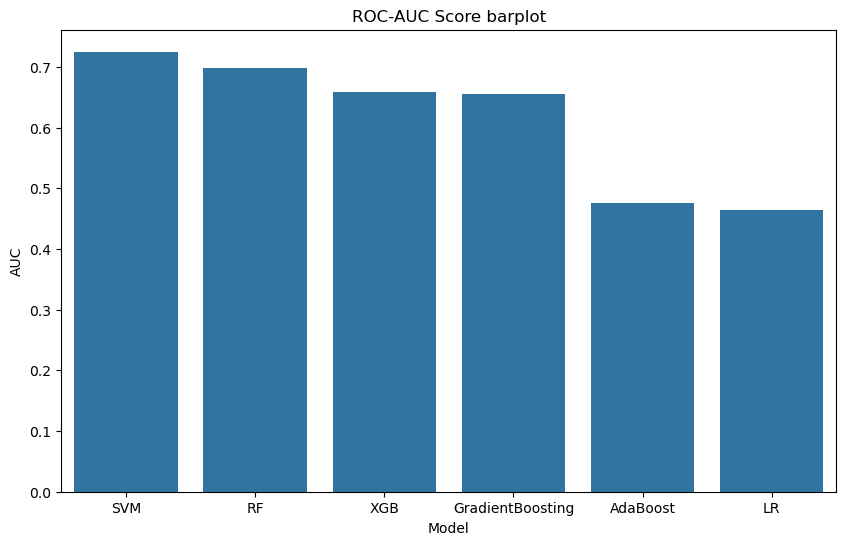

In [36]:
plt.figure(figsize = (10, 6))
sns.barplot(x = 'Model', y = 'AUC', data = results_ord)
plt.title('ROC-AUC Score barplot')
plt.show()

## Analysis on the best model

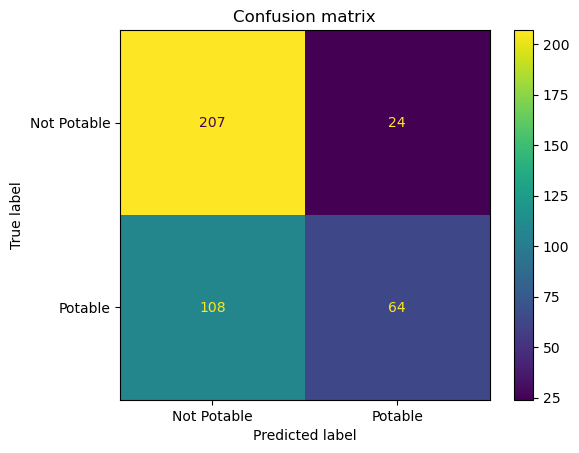

In [28]:
model = SVC(probability = True) ##Model specification 

pipe_svm = Pipeline([('Scaler', StandardScaler()), 
                     ('Model', model)]) ## Pipeline of SVM model

pipe_svm.fit(x_train, y_train) ##Model training 

y_pred = pipe_svm.predict(x_test) ##Model prediction 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

cm = confusion_matrix(y_test, y_pred) ##Confusion matrix 
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Not Potable', 'Potable'])
disp.plot()
plt.title('Confusion matrix')
plt.show()


In [24]:
from sklearn.metrics import classification_report 
print('Classification report:')
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       231
           1       0.73      0.37      0.49       172

    accuracy                           0.67       403
   macro avg       0.69      0.63      0.63       403
weighted avg       0.69      0.67      0.64       403



## Threshold identification

In [13]:
from sklearn.metrics import precision_recall_curve 

y_proba =  pipe_svm.predict_proba(x_test)[:,1]

precision, recall, threshold = precision_recall_curve(y_test, y_proba)

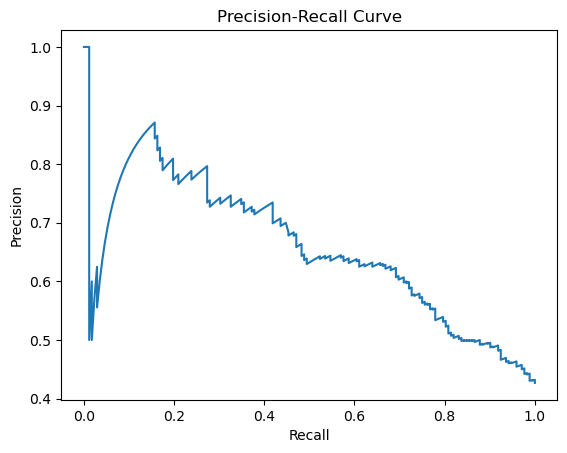

In [18]:
##Graphics

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [15]:
f1_scores = 2 * (precision * recall) / (precision + recall) #F1 score calculation 

best_index = np.argmax(f1_scores) ##Recover the best F1 score index 
best_threshold = threshold[best_index] ##Identification of the threshold 

print("Best threshold:", best_threshold) 
print("Best F1:", f1_scores[best_index])

Best threshold: 0.39593542321187936
Best F1: 0.6556473829201103


## Classification with the best threshold 

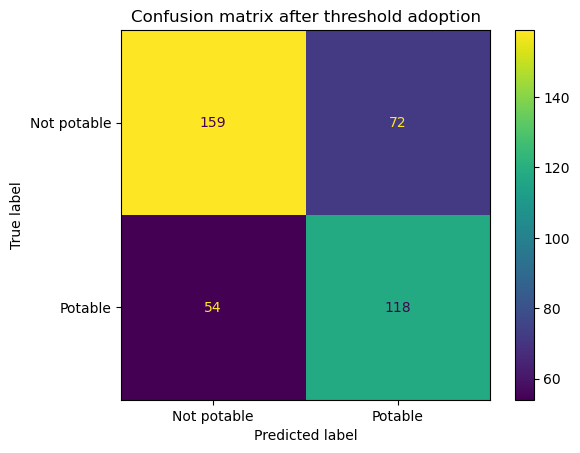

In [30]:
y_pred1 = (y_proba > best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred1) 
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Not potable', 'Potable']) 
disp.plot()
plt.title('Confusion matrix after threshold adoption')
plt.show()

In [31]:
from sklearn.metrics import classification_report 
print('Classification report after threshold:')
print(classification_report(y_test, y_pred1))

Classification report after threshold:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72       231
           1       0.62      0.69      0.65       172

    accuracy                           0.69       403
   macro avg       0.68      0.69      0.68       403
weighted avg       0.69      0.69      0.69       403

